In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors 

from astropy.io import fits 
from astropy.wcs import WCS 
import astropy.units as u 

import healpy as hp 
from reproject import reproject_from_healpix 
from reproject.mosaicking import find_optimal_celestial_wcs 
from reproject import reproject_to_healpix
from scipy import stats

In [31]:
fn = '~/ResearchSummer26/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamDat = fits.getdata(fn) 
whamHdr = fits.getheader(fn)


In [32]:
velChannelWidth = abs(whamHdr['CDELT3']) 
# whamMap = np.nansum(whamDat, axis = 0) * velChannelWidth / 1e6 
whamMap = np.nansum(whamDat, axis = 0) * velChannelWidth / 1000

whamWCS3D = WCS(whamHdr) 
whamWCS2D = whamWCS3D.dropaxis(2)

wham2DHeader = whamWCS2D.to_header() 
wham2DHeader['NAXIS'] = 2
wham2DHeader['NAXIS1'] = whamHeader['NAXIS1']   # 
wham2DHeader['NAXIS2'] = whamHeader['NAXIS2'] 

 [astropy.io.fits.verify]


In [33]:
#mask before reprojection to hpx 
negativeMask = whamMap <= 0 

upperThreshold = np.nanpercentile(whamMap[whamMap > 0], 99.9)
outlierMask = whamMap > upperThreshold 

noiseMask = whamMap < 0.3 

nanMask = ~np.isfinite(whamMap)

badMask = negativeMask | outlierMask | noiseMask | nanMask 
whamMapClean = whamMap.copy() 
whamMapClean[badMask] = np.nan 

print(f"Pixels masked: {np.sum(badMask)} / {whamMap.size} "
      f"({100 * np.sum(badMask) / whamMap.size:.1f}%)")
print(f"  Negative: {np.sum(negativeMask)}")
print(f"  Outlier:  {np.sum(outlierMask)}")
print(f"  Low SNR:  {np.sum(noiseMask)}")
print(f"  NaN:      {np.sum(nanMask)}")

Pixels masked: 31228 / 1036800 (3.0%)
  Negative: 626
  Outlier:  1037
  Low SNR:  30191
  NaN:      0


In [34]:
whamHealpix, whamFootprint = reproject_to_healpix( 
    (whamMapClean, wham2DHeader), 
    coord_system_out = 'galactic', 
    nside = 128, 
    order = 'bilinear', 
    nested=False
)

In [35]:
whamHealpix[whamFootprint < 0.5] = np.nan 

whamHealpix[whamHealpix <= 0] = np.nan

print("Valid HEALPix pixels:", np.sum(np.isfinite(whamHealpix)))
print("Expected sky fraction for WHAM (~north of dec -30°): ~75%")
print(f"Got: {np.sum(np.isfinite(whamHealpix)) / hp.nside2npix(128) * 100:.1f}%")

Valid HEALPix pixels: 192653
Expected sky fraction for WHAM (~north of dec -30°): ~75%
Got: 98.0%


In [36]:
hp.write_map(
    'wham_halpha_healpix.fits',
    whamHealpix,
    coord='G',
    column_names=['HALPHA'],
    extra_header=[
        ('BUNIT',   'R',      'Rayleighs, integrated over velocity'),
        ('NSIDE',   128,    'HEALPix NSIDE'),
        ('HISTORY', 'Collapsed WHAM DR1 cube over all 162 velocity channels'),
        ('HISTORY', 'Integrated intensity: sum * CDELT3 / 1000 = Rayleighs'),
        ('HISTORY', 'Masked: negatives, outliers >99.9%, SNR floor 0.3 R'),
        ('HISTORY', 'Reprojected GLON-CAR -> HEALPix RING using reproject')
    ],
    overwrite=True
)

setting the output map dtype to [dtype('float32')]


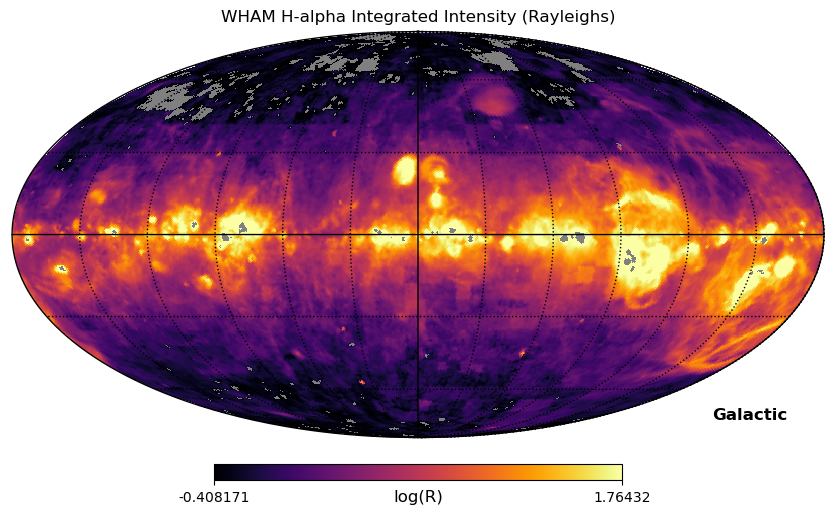

In [37]:
validPix = whamHealpix[np.isfinite(whamHealpix)] 

hp.mollview( 
    np.log10(whamHealpix), 
    coord = ['G'], 
    cmap = 'inferno', 
    title = 'WHAM H-alpha Integrated Intensity (Rayleighs)', 
    unit = 'log(R)', 
    min = np.log10(np.nanpercentile(validPix, 2)), 
    max = np.log10(np.nanpercentile(validPix, 98))
)
hp.graticule() 
plt.savefig('wham_healpix_mollview.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [38]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_M0_gal.hpx.fits'
dragonsM0Data = fits.getdata(fn) 
dragonsM0Header = fits.getheader(fn) 

In [39]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_M1_gal.hpx.fits'
dragonsM1Data = fits.getdata(fn) 
dragonsM1Header = fits.getheader(fn)


In [40]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_m2_gal.hpx.fits'
dragonsm2Data = fits.getdata(fn) 
dragonsm2header = fits.getheader(fn) 
dragonsM2Data = dragonsm2Data**2


In [41]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_sigma_Kgal.hpx.fits'
dragonsSigmaData = fits.getdata(fn).flatten() 
dragonsSigmaHeader = fits.getheader(fn) 

In [42]:
nside = 128 
npix = hp.nside2npix(nside) 

In [43]:
snrMap = dragonsM0Data / dragonsSigmaData 
snrMask = snrMap < 5.0 

nPix = hp.nside2npix(nside)
allPixIdx = np.arange(nPix) 
theta, phi = hp.pix2ang(nside, allPixIdx, nest=False) 
gallat = 90.0 - np.degrees(theta) 
planeMask = np.abs(gallat) < 5.0

nanMask = ( 
    ~np.isfinite(dragonsM0Data) | 
    ~np.isfinite(dragonsM1Data) | 
    ~np.isfinite(dragonsM2Data) | 
    ~np.isfinite(dragonsSigmaData) | 
    ~np.isfinite(whamHealpix) 
) 

negativem2Mask = dragonsM2Data < 0 

combinedBadMask = snrMask | planeMask | nanMask | negativem2Mask 

print(f"Total pixels:          {nPix}")
print(f"  SNR < 5 masked:      {np.sum(snrMask)}")
print(f"  Galactic plane:      {np.sum(planeMask)}")
print(f"  NaN in any map:      {np.sum(nanMask)}")
print(f"  Negative m2:         {np.sum(negativem2Mask)}")
print(f"  Total masked:        {np.sum(combinedBadMask)}")
print(f"  Pixels remaining:    {np.sum(~combinedBadMask)} "
      f"({100 * np.sum(~combinedBadMask) / nPix:.1f}%)")

Total pixels:          196608
  SNR < 5 masked:      0
  Galactic plane:      16896
  NaN in any map:      70685
  Negative m2:         0
  Total masked:        79774
  Pixels remaining:    116834 (59.4%)


In [44]:
#apply mask to wham 
whamValid = whamHealpix[~combinedBadMask] 
m1Valid = dragonsM1Data[~combinedBadMask] 
m2Valid = dragonsM2Data[~combinedBadMask] 
m0Valid = dragonsM2Data[~combinedBadMask]

snrValid = snrMap[~combinedBadMask] 

/tmp/ipykernel_253514/2327990726.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


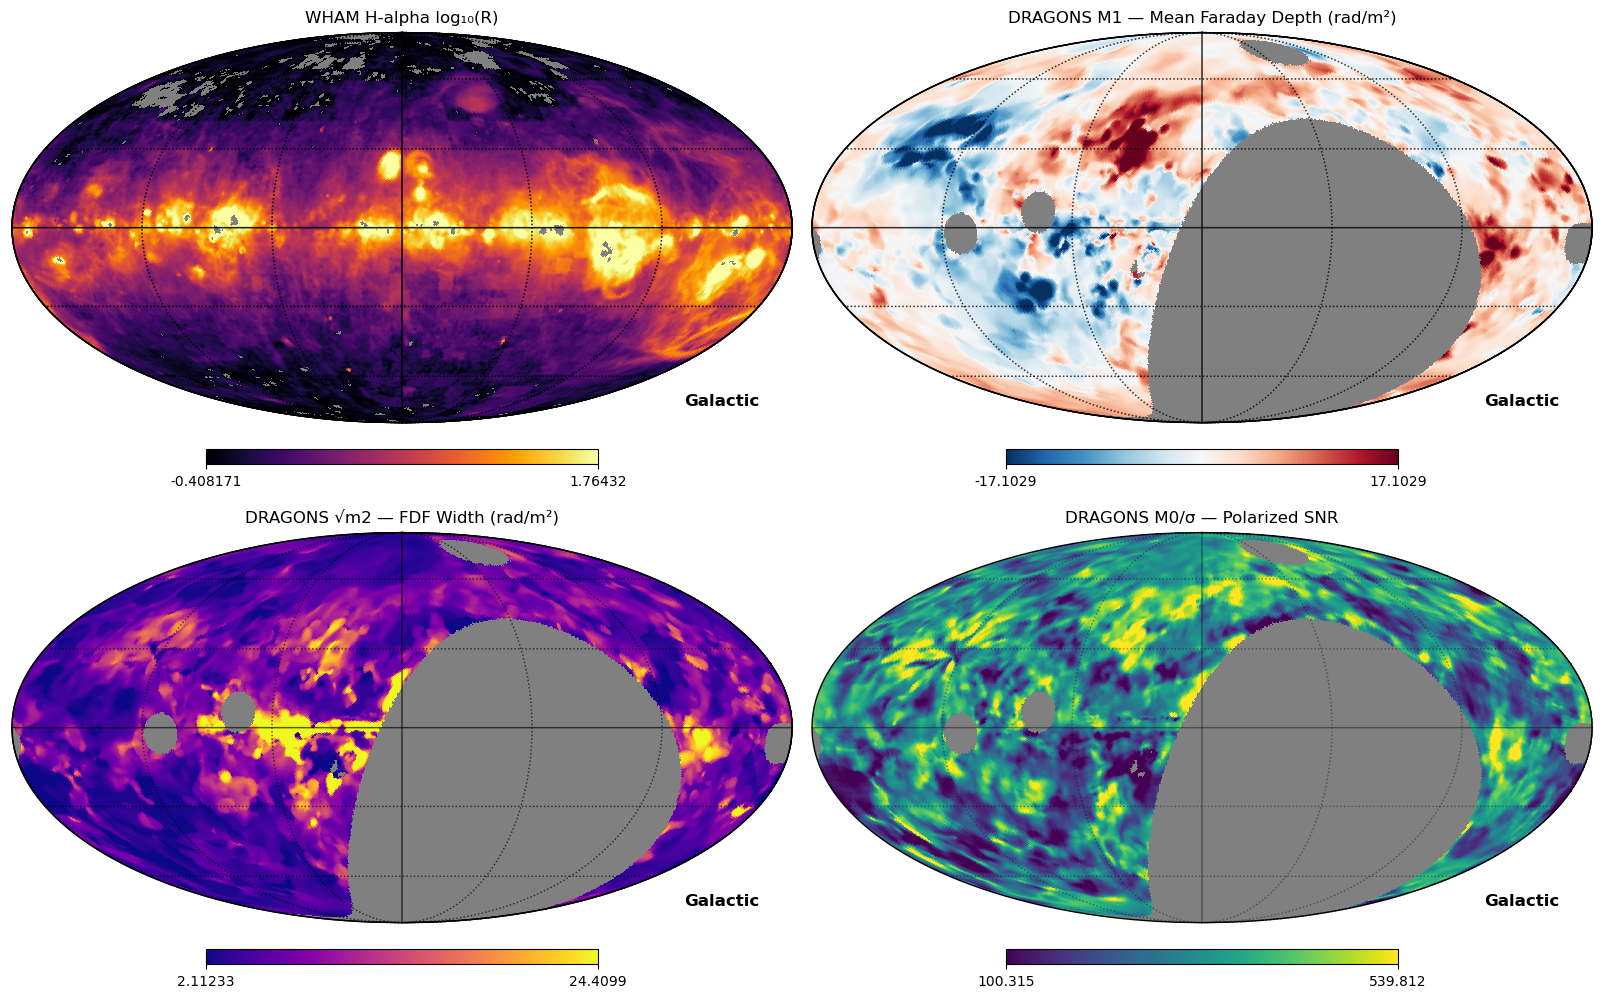

In [45]:
fig = plt.figure(figsize=(16, 10))

maps = [
    (np.log10(whamHealpix), 'WHAM H-alpha log₁₀(R)',                   'inferno',  False),
    (dragonsM1Data,         'DRAGONS M1 — Mean Faraday Depth (rad/m²)', 'RdBu_r',   True),
    (np.sqrt(dragonsM2Data),'DRAGONS √m2 — FDF Width (rad/m²)',         'plasma',   False),
    (snrMap,                'DRAGONS M0/σ — Polarized SNR',             'viridis',  False),
]

for i, (data, title, cmap, centerZero) in enumerate(maps):
    validData = data[np.isfinite(data)]
    vmin = np.nanpercentile(validData, 2)
    vmax = np.nanpercentile(validData, 98)
    if centerZero:
        vLim = np.nanpercentile(np.abs(validData), 98)
        vmin, vmax = -vLim, vLim

    hp.mollview(
        data,
        coord=['G'],
        xsize=1600,
        cmap=cmap,
        min=vmin,
        max=vmax,
        title=title,
        sub=(2, 2, i + 1),   # tells healpy to draw into subplot slot i+1
        fig=fig.number        # attach to our figure
    )
    hp.graticule(dpar=30, dmer=60, alpha=0.4)

plt.tight_layout()
plt.savefig('dragons_wham_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
#binning h-alpha 
lowCut = np.nanpercentile(whamValid, 33)
highCut = np.nanpercentile(whamValid, 67) 

lowMask = whamValid <= lowCut 
highMask = whamValid >= highCut 

m1Low = m1Valid[lowMask] 
m1High = m1Valid[highMask]

m2Low = m2Valid[lowMask] 
m2High = m2Valid[highMask] 



NameError: name 'pM1' is not defined

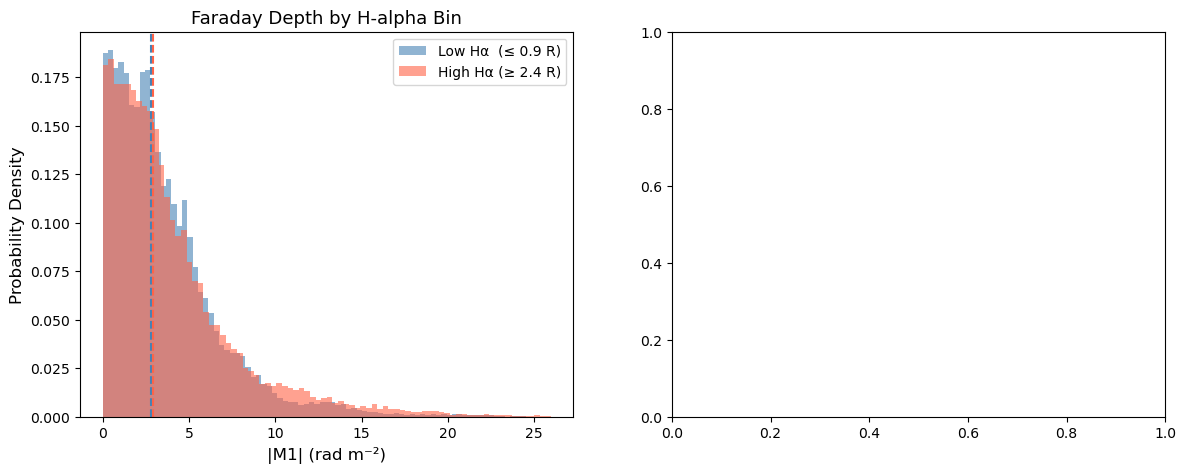

In [47]:
# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: |M1| distributions
axes[0].hist(np.abs(m1Low),  bins=80, alpha=0.6, density=True,
             color='steelblue', label=f'Low Hα  (≤ {lowCut:.1f} R)')
axes[0].hist(np.abs(m1High), bins=80, alpha=0.6, density=True,
             color='tomato',    label=f'High Hα (≥ {highCut:.1f} R)')
axes[0].axvline(np.median(np.abs(m1Low)),  color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(np.median(np.abs(m1High)), color='tomato',    linestyle='--', linewidth=1.5)
axes[0].set_xlabel('|M1| (rad m⁻²)', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
axes[0].set_title('Faraday Depth by H-alpha Bin', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].text(0.97, 0.95, f'p = {pM1:.2e}', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Panel 2: m2 distributions
axes[1].hist(m2Low,  bins=80, alpha=0.6, density=True,
             color='steelblue', label=f'Low Hα  (≤ {lowCut:.1f} R)')
axes[1].hist(m2High, bins=80, alpha=0.6, density=True,
             color='tomato',    label=f'High Hα (≥ {highCut:.1f} R)')
axes[1].axvline(np.median(m2Low),  color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(np.median(m2High), color='tomato',    linestyle='--', linewidth=1.5)
axes[1].set_xlabel('m2 (rad² m⁻⁴)', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].set_title('Faraday Complexity by H-alpha Bin', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].text(0.97, 0.95, f'p = {pM2:.2e}', transform=axes[1].transAxes,
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('faraday_halpha_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
print("\n=== |M1| (Peak Faraday Depth) ===")
print(f"  Low  Hα: mean |M1| = {np.mean(np.abs(m1Low)):.2f}  "
      f"median = {np.median(np.abs(m1Low)):.2f}  "
      f"std = {np.std(m1Low):.2f}")
print(f"  High Hα: mean |M1| = {np.mean(np.abs(m1High)):.2f}  "
      f"median = {np.median(np.abs(m1High)):.2f}  "
      f"std = {np.std(m1High):.2f}")

print("\n=== m2 (Faraday Complexity) ===")
print(f"  Low  Hα: mean m2 = {np.mean(m2Low):.2f}  "
      f"median = {np.median(m2Low):.2f}  "
      f"std = {np.std(m2Low):.2f}")
print(f"  High Hα: mean m2 = {np.mean(m2High):.2f}  "
      f"median = {np.median(m2High):.2f}  "
      f"std = {np.std(m2High):.2f}")

# --- Mann-Whitney U tests ---
uStatM1, pM1 = stats.mannwhitneyu(np.abs(m1High), np.abs(m1Low), alternative='greater')
uStatM2, pM2 = stats.mannwhitneyu(m2High, m2Low, alternative='greater')

print(f"\n  M1 Mann-Whitney: U = {uStatM1:.1f},  p = {pM1:.4e}")
print(f"  m2 Mann-Whitney: U = {uStatM2:.1f},  p = {pM2:.4e}")


=== |M1| (Peak Faraday Depth) ===
  Low  Hα: mean |M1| = 3.62  median = 2.83  std = 4.64
  High Hα: mean |M1| = 4.00  median = 2.95  std = 5.47

=== m2 (Faraday Complexity) ===
  Low  Hα: mean m2 = 35.48  median = 22.93  std = 38.97
  High Hα: mean m2 = 99.69  median = 46.86  std = 179.75

  M1 Mann-Whitney: U = 767917074.0,  p = 7.1317e-16
  m2 Mann-Whitney: U = 997090097.0,  p = 0.0000e+00


In [49]:

nBins = 50
percentileEdges = np.linspace(0, 100, nBins + 1)
binEdges = np.nanpercentile(whamValid, percentileEdges)
binCentres = 0.5 * (binEdges[:-1] + binEdges[1:])

# Storage arrays
medianM1    = np.zeros(nBins)
medianM2    = np.zeros(nBins)
meanM1      = np.zeros(nBins)
meanM2      = np.zeros(nBins)
errM1       = np.zeros(nBins)
errM2       = np.zeros(nBins)
p16M1       = np.zeros(nBins)
p84M1       = np.zeros(nBins)
p16M2       = np.zeros(nBins)
p84M2       = np.zeros(nBins)
pixelCounts = np.zeros(nBins)

for i in range(nBins):
    binMask = (whamValid >= binEdges[i]) & (whamValid < binEdges[i + 1])
    
    m1Bin = np.abs(m1Valid[binMask])
    m2Bin = m2Valid[binMask]
    pixelCounts[i] = np.sum(binMask)

    medianM1[i] = np.median(m1Bin)
    medianM2[i] = np.median(m2Bin)
    meanM1[i]   = np.mean(m1Bin)
    meanM2[i]   = np.mean(m2Bin)

    # Uncertainty on median via bootstrap
    nBoots = 500
    bootM1 = np.array([np.median(np.abs(np.random.choice(m1Bin, size=len(m1Bin), replace=True)))
                       for _ in range(nBoots)])
    bootM2 = np.array([np.median(np.random.choice(m2Bin, size=len(m2Bin), replace=True))
                       for _ in range(nBoots)])
    errM1[i] = np.std(bootM1)
    errM2[i] = np.std(bootM2)

    print(f"Bin {i+1:2d}: Hα [{binEdges[i]:.2f} – {binEdges[i+1]:.2f}] R  "
          f"n={int(pixelCounts[i]):6d}  "
          f"median|M1|={medianM1[i]:.2f}  "
          f"medianM2={medianM2[i]:.2f}")

Bin  1: Hα [0.30 – 0.37] R  n=  2337  median|M1|=1.90  medianM2=18.67
Bin  2: Hα [0.37 – 0.41] R  n=  2337  median|M1|=2.22  medianM2=19.97
Bin  3: Hα [0.41 – 0.45] R  n=  2336  median|M1|=2.37  medianM2=18.47
Bin  4: Hα [0.45 – 0.47] R  n=  2337  median|M1|=2.42  medianM2=19.97
Bin  5: Hα [0.47 – 0.50] R  n=  2337  median|M1|=2.61  medianM2=20.53
Bin  6: Hα [0.50 – 0.53] R  n=  2336  median|M1|=2.62  medianM2=20.83
Bin  7: Hα [0.53 – 0.55] R  n=  2337  median|M1|=2.58  medianM2=21.18
Bin  8: Hα [0.55 – 0.58] R  n=  2337  median|M1|=2.78  medianM2=22.36
Bin  9: Hα [0.58 – 0.61] R  n=  2336  median|M1|=2.76  medianM2=23.58
Bin 10: Hα [0.61 – 0.64] R  n=  2337  median|M1|=3.06  medianM2=25.24
Bin 11: Hα [0.64 – 0.67] R  n=  2337  median|M1|=3.16  medianM2=25.02
Bin 12: Hα [0.67 – 0.70] R  n=  2336  median|M1|=3.09  medianM2=24.49
Bin 13: Hα [0.70 – 0.74] R  n=  2337  median|M1|=3.32  medianM2=24.25
Bin 14: Hα [0.74 – 0.77] R  n=  2337  median|M1|=3.77  medianM2=25.98
Bin 15: Hα [0.77 – 0

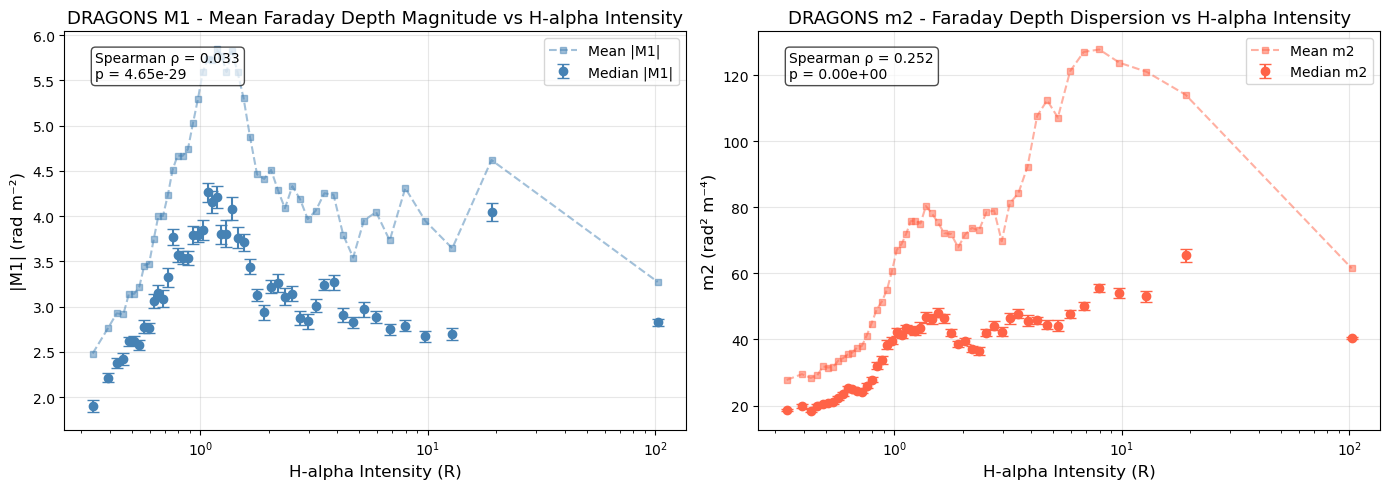

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: |M1| vs H-alpha ---
axes[0].errorbar(
    binCentres, medianM1, yerr=errM1,
    fmt='o', color='steelblue', capsize=4,
    markersize=6, linewidth=1.5, label='Median |M1|'
)
axes[0].plot(binCentres, meanM1, 's--', color='steelblue',
             alpha=0.5, markersize=5, label='Mean |M1|')
axes[0].set_xlabel('H-alpha Intensity (R)', fontsize=12)
axes[0].set_ylabel('|M1| (rad m⁻²)', fontsize=12)
axes[0].set_title('DRAGONS M1 - Mean Faraday Depth Magnitude vs H-alpha Intensity', fontsize=13)
axes[0].set_xscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Spearman correlation
rhoM1, pRhoM1 = stats.spearmanr(whamValid, np.abs(m1Valid))
axes[0].text(0.05, 0.95,
             f'Spearman ρ = {rhoM1:.3f}\np = {pRhoM1:.2e}',
             transform=axes[0].transAxes, fontsize=10,
             va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# --- Panel 2: m2 vs H-alpha ---
axes[1].errorbar(
    binCentres, medianM2, yerr=errM2,
    fmt='o', color='tomato', capsize=4,
    markersize=6, linewidth=1.5, label='Median m2'
)
axes[1].plot(binCentres, meanM2, 's--', color='tomato',
             alpha=0.5, markersize=5, label='Mean m2')
axes[1].set_xlabel('H-alpha Intensity (R)', fontsize=12)
axes[1].set_ylabel('m2 (rad² m⁻⁴)', fontsize=12)
axes[1].set_title('DRAGONS m2 - Faraday Depth Dispersion vs H-alpha Intensity', fontsize=13)
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

rhoM2, pRhoM2 = stats.spearmanr(whamValid, m2Valid)
axes[1].text(0.05, 0.95,
             f'Spearman ρ = {rhoM2:.3f}\np = {pRhoM2:.2e}',
             transform=axes[1].transAxes, fontsize=10,
             va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('faraday_halpha_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
belowMask = whamValid < 1.0 
aboveMask = whamValid >=1.0 

print(f"Pixels below 1R: {np.sum(belowMask)}") 
print(f"Pixels above 1R: {np.sum(aboveMask)}") 

rhoM1Below, pRhoM1Below = stats.spearmanr(whamValid[belowMask], np.abs(m1Valid[belowMask]))
rhoM1Above, pRhoM1Above = stats.spearmanr(whamValid[aboveMask], np.abs(m1Valid[aboveMask]))

rhoM2Below, pRhoM2Below = stats.spearmanr(whamValid[belowMask], m2Valid[belowMask])
rhoM2Above, pRhoM2Above = stats.spearmanr(whamValid[aboveMask], m2Valid[aboveMask])

print(f"\n |M1| above 1 R: rho = {rhoM1Above:.3f}, p = {pRhoM1Above:.3e}")
print(f"\n |M1| below 1 R: rho = {rhoM1Below:.3f}, p = {pRhoM1Above:.3e}")

print(f"\n m2 below 1 R: rho= {rhoM2Below:.3f}, p = {pRhoM2Below:.3e}")
print(f" m2 above 1 R: rho = {rhoM2Above:.3f}, p = {pRhoM2Above:.3e}")

Pixels below 1R: 44308
Pixels above 1R: 72526

 |M1| above 1 R: rho = -0.113, p = 1.200e-205

 |M1| below 1 R: rho = 0.211, p = 1.200e-205

 m2 below 1 R: rho= 0.198, p = 0.000e+00
 m2 above 1 R: rho = 0.057, p = 6.481e-53


In [52]:
# --- Split analysis at 1 R threshold ---
belowMask = whamValid < 1.0
aboveMask = whamValid >= 1.0

print(f"Pixels below 1 R: {np.sum(belowMask)}")
print(f"Pixels above 1 R: {np.sum(aboveMask)}")

# --- Spearman correlations in each regime ---
rhoM1Below, pRhoM1Below = stats.spearmanr(whamValid[belowMask], np.abs(m1Valid[belowMask]))
rhoM1Above, pRhoM1Above = stats.spearmanr(whamValid[aboveMask], np.abs(m1Valid[aboveMask]))

rhoM2Below, pRhoM2Below = stats.spearmanr(whamValid[belowMask], m2Valid[belowMask])
rhoM2Above, pRhoM2Above = stats.spearmanr(whamValid[aboveMask], m2Valid[aboveMask])

print("\n=== Spearman Correlations ===")
print(f"\n  |M1| below 1 R: ρ = {rhoM1Below:.3f},  p = {pRhoM1Below:.3e}")
print(f"  |M1| above 1 R: ρ = {rhoM1Above:.3f},  p = {pRhoM1Above:.3e}")
print(f"\n  m2  below 1 R: ρ = {rhoM2Below:.3f},  p = {pRhoM2Below:.3e}")
print(f"  m2  above 1 R: ρ = {rhoM2Above:.3f},  p = {pRhoM2Above:.3e}")

# --- Mann Whitney comparing < 1R vs > 1R ---
uStatM1, pM1 = stats.mannwhitneyu(np.abs(m1Valid[aboveMask]), 
                                   np.abs(m1Valid[belowMask]), 
                                   alternative='two-sided')
uStatM2, pM2 = stats.mannwhitneyu(m2Valid[aboveMask], 
                                   m2Valid[belowMask], 
                                   alternative='two-sided')

print("\n=== Mann-Whitney: above vs below 1 R ===")
print(f"  |M1|: U = {uStatM1:.1f},  p = {pM1:.3e}")
print(f"  m2:   U = {uStatM2:.1f},  p = {pM2:.3e}")

# --- Summary statistics in each regime ---
print("\n=== Summary Statistics ===")
print(f"\n  |M1| below 1 R → mean = {np.mean(np.abs(m1Valid[belowMask])):.2f}  "
      f"median = {np.median(np.abs(m1Valid[belowMask])):.2f}  "
      f"std = {np.std(np.abs(m1Valid[belowMask])):.2f}")
print(f"  |M1| above 1 R → mean = {np.mean(np.abs(m1Valid[aboveMask])):.2f}  "
      f"median = {np.median(np.abs(m1Valid[aboveMask])):.2f}  "
      f"std = {np.std(np.abs(m1Valid[aboveMask])):.2f}")

print(f"\n  m2 below 1 R → mean = {np.mean(m2Valid[belowMask]):.2f}  "
      f"median = {np.median(m2Valid[belowMask]):.2f}  "
      f"std = {np.std(m2Valid[belowMask]):.2f}")
print(f"  m2 above 1 R → mean = {np.mean(m2Valid[aboveMask]):.2f}  "
      f"median = {np.median(m2Valid[aboveMask]):.2f}  "
      f"std = {np.std(m2Valid[aboveMask]):.2f}")

Pixels below 1 R: 44308
Pixels above 1 R: 72526

=== Spearman Correlations ===

  |M1| below 1 R: ρ = 0.211,  p = 0.000e+00
  |M1| above 1 R: ρ = -0.113,  p = 1.200e-205

  m2  below 1 R: ρ = 0.198,  p = 0.000e+00
  m2  above 1 R: ρ = 0.057,  p = 6.481e-53

=== Mann-Whitney: above vs below 1 R ===
  |M1|: U = 1714161477.0,  p = 3.393e-82
  m2:   U = 2068309669.0,  p = 0.000e+00

=== Summary Statistics ===

  |M1| below 1 R → mean = 3.81  median = 2.93  std = 3.43
  |M1| above 1 R → mean = 4.57  median = 3.22  std = 4.58

  m2 below 1 R → mean = 38.20  median = 24.16  std = 43.62
  m2 above 1 R → mean = 87.35  median = 44.75  std = 147.29


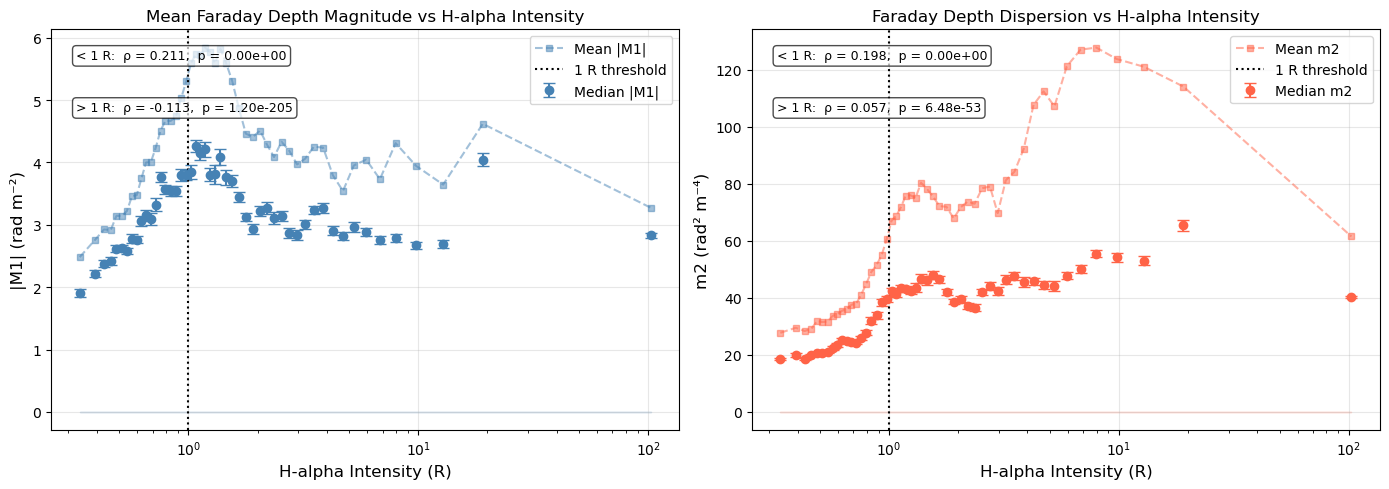

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: |M1| ---
axes[0].fill_between(binCentres, p16M1, p84M1, alpha=0.25, color='steelblue')
axes[0].errorbar(binCentres, medianM1, yerr=errM1, fmt='o', color='steelblue',
                 capsize=4, markersize=6, linewidth=1.5, label='Median |M1|')
axes[0].plot(binCentres, meanM1, 's--', color='steelblue',
             alpha=0.5, markersize=5, label='Mean |M1|')
axes[0].axvline(1.0, color='black', linestyle=':', linewidth=1.5, label='1 R threshold')
axes[0].text(0.04, 0.95, f'< 1 R:  ρ = {rhoM1Below:.3f},  p = {pRhoM1Below:.2e}',
             transform=axes[0].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].text(0.04, 0.82, f'> 1 R:  ρ = {rhoM1Above:.3f},  p = {pRhoM1Above:.2e}',
             transform=axes[0].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].set_xlabel('H-alpha Intensity (R)', fontsize=12)
axes[0].set_ylabel('|M1| (rad m⁻²)', fontsize=12)
axes[0].set_title('Mean Faraday Depth Magnitude vs H-alpha Intensity', fontsize=12)
axes[0].set_xscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: m2 ---
axes[1].fill_between(binCentres, p16M2, p84M2, alpha=0.25, color='tomato')
axes[1].errorbar(binCentres, medianM2, yerr=errM2, fmt='o', color='tomato',
                 capsize=4, markersize=6, linewidth=1.5, label='Median m2')
axes[1].plot(binCentres, meanM2, 's--', color='tomato',
             alpha=0.5, markersize=5, label='Mean m2')
axes[1].axvline(1.0, color='black', linestyle=':', linewidth=1.5, label='1 R threshold')
axes[1].text(0.04, 0.95, f'< 1 R:  ρ = {rhoM2Below:.3f},  p = {pRhoM2Below:.2e}',
             transform=axes[1].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1].text(0.04, 0.82, f'> 1 R:  ρ = {rhoM2Above:.3f},  p = {pRhoM2Above:.2e}',
             transform=axes[1].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1].set_xlabel('H-alpha Intensity (R)', fontsize=12)
axes[1].set_ylabel('m2 (rad² m⁻⁴)', fontsize=12)
axes[1].set_title('Faraday Depth Dispersion vs H-alpha Intensity', fontsize=12)
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('faraday_halpha_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
fn = '~/ResearchSummer26/HI4Pi/NHI_HPX.fits'
nhiDat = fits.getdata(fn, ext=1).field('NHI') 
nhiHdr = fits.getheader(fn, ext = 1)


In [77]:
HIHdr

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   48 / length of dimension 1                          
NAXIS2  =             12582912 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    6 / number of table fields                         
TTYPE1  = 'HPXINDEX'                                                            
TFORM1  = '1K      '                                                            
TTYPE2  = 'RA2000  '                                                            
TFORM2  = '1D      '                                                            
TUNIT2  = 'deg     '        

In [78]:
hdul = fits.open('~/ResearchSummer26/HI4Pi/NHI_HPX.fits')
hdul.info()
hdul.close()

Filename: /home/justin/ResearchSummer26/HI4Pi/NHI_HPX.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (1,)   int64   
  1  HI4PI-HPX     1 BinTableHDU     45   12582912R x 6C   [1K, 1D, 1D, 1D, 1D, 1D]   


/tmp/ipykernel_253514/614264257.py:2: RuntimeWarning: invalid value encountered in log10
  np.log10(nhiDat),
/tmp/ipykernel_253514/614264257.py:7: RuntimeWarning: invalid value encountered in log10
  min=np.nanmin(np.log10(nhiDat)),
/tmp/ipykernel_253514/614264257.py:8: RuntimeWarning: invalid value encountered in log10
  max=np.nanmax(np.log10(nhiDat))


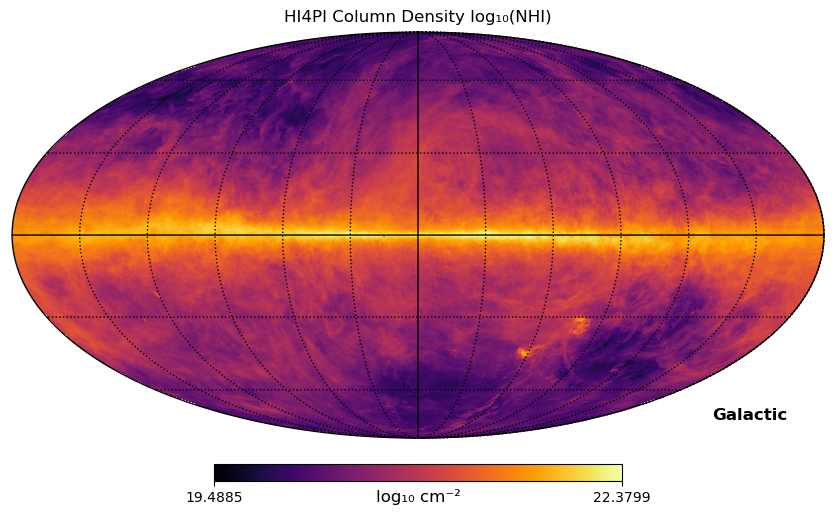

Min  NHI: -1.600e+21 cm⁻²
Max  NHI: 2.398e+22 cm⁻²
Mean NHI: 1.226e+21 cm⁻²
Median NHI: 5.292e+20 cm⁻²
NaN count: 0


In [83]:

hp.mollview(
    np.log10(nhiDat),
    coord=['G'],
    cmap='inferno',
    title='HI4PI Column Density log₁₀(NHI)',
    unit='log₁₀ cm⁻²',
    min=np.nanmin(np.log10(nhiDat)),
    max=np.nanmax(np.log10(nhiDat))
)
hp.graticule()
plt.savefig('hi4pi_nhi_mollview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Min  NHI: {np.nanmin(nhiDat):.3e} cm⁻²")
print(f"Max  NHI: {np.nanmax(nhiDat):.3e} cm⁻²")
print(f"Mean NHI: {np.nanmean(nhiDat):.3e} cm⁻²")
print(f"Median NHI: {np.nanmedian(nhiDat):.3e} cm⁻²")
print(f"NaN count: {np.sum(~np.isfinite(nhiDat))}")

In [87]:
#masking Hi4Pi data 
nhiNpix = nhiDat.shape[0] 
nhiNside = hp.npix2nside(nhiNpix)
allPixIdx = np.arange(nhiNpix) 
theta, phi = hp.pix2ang(nhiNside, allPixIdx, nest = False) 
galLat = 90.0 - np.degrees(theta) 
nhiPlaneMask = np.abs(galLat) < 5.0 

nhiNegMask = nhiDat < 0 

nhiNanMask = ~np.isfinite(nhiDat) 

nhiUpperThresh = np.nanpercentile(nhiDat[~nhiPlaneMask], 99.9)
nhiHVCMask = nhiDat > nhiUpperThresh 

nhiCombinedBadMask = nhiPlaneMask | nhiNegMask | nhiNanMask | nhiHVCMask

print(f"Total pixels: {nhiNpix} \nGalactic Plane: {np.sum(nhiPlaneMask)}")
print(f"negatives/zeroes: {np.sum(nhiNegMask)}, \nNaN: {np.sum(nhiNanMask)}")
print(f"HVCs: {np.sum(nhiHVCMask)}, \nTotal mask: {np.sum(nhiCombinedBadMask)}")
print(f"Pixels remaining: {np.sum(~nhiCombinedBadMask)}")
print(f"Percentage Masked: {np.sum(nhiCombinedBadMask)/np.sum(~nhiCombinedBadMask) * 100}")

Total pixels: 12582912 
Galactic Plane: 1093632
negatives/zeroes: 51, 
NaN: 0
HVCs: 534980, 
Total mask: 1105129
Pixels remaining: 11477783
Percentage Masked: 9.628418658899546


In [88]:
nhiDegraded = hp.ud_grade(nhiDat, nside_out=128, order_in='RING', order_out='RING')

In [95]:
nhiCombinedBadMaskDegraded = hp.ud_grade( 
    nhiCombinedBadMask.astype(float), nside_out = 128) > 0.5

jointBadMask = combinedBadMask | nhiCombinedBadMaskDegraded 

nhiValid = nhiDat[~jointBadMask] if nhiNside == nside else nhiDegraded[~jointBadMask]
whamValid2 = whamHealpix[~jointBadMask] 
m1Valid2 = dragonsM1Data[~jointBadMask] 
m2Valid2 = dragonsM2Data[~jointBadMask] 

print(f"Joint valid pixels: {np.sum(~jointBadMask)}")

Joint valid pixels: 116725


In [97]:
rhoNHIM1, pNHIM1 = stats.spearmanr(np.log10(nhiValid), np.abs(m1Valid2)) 
rhoNHIM2, pNHIM2 = stats.spearmanr(np.log10(nhiValid), m2Valid2)

print(f" vs |M1|: rho = {rhoNHIM1:.3f}, p = {pNHIM1:.3e}")
print(f" vs m2: rho = {rhoNHIM2:.3f}, p = {pNHIM2:.3e}") 

nhiThresh = 10**20.5

belowNHIMask = nhiValid < nhiThresh 
aboveNHIMask = nhiValid > nhiThresh 


print(f"\nPixels below 10^20.5 cm^-2: {np.sum(belowNHIMask)}")
print(f"\nPixels above              : {np.sum(aboveNHIMask)}")

 vs |M1|: rho = -0.020, p = 1.641e-11
 vs m2: rho = 0.138, p = 0.000e+00

Pixels below 10^20.5 cm^-2: 35621

Pixels above              : 81104


In [140]:
rhoM1Below, pM1Below = stats.spearmanr(np.log10(nhiValid[belowNHIMask]), np.abs(m1Valid2[belowNHIMask]))
rhoM1Above, pM1Above = stats.spearmanr(np.log10(nhiValid[aboveNHIMask]), np.abs(m1Valid2[aboveNHIMask]))
rhoM2Below, pM2Below = stats.spearmanr(np.log10(nhiValid[belowNHIMask]), m2Valid2[belowNHIMask])
rhoM2Above, pM2Above = stats.spearmanr(np.log10(nhiValid[aboveNHIMask]), m2Valid2[aboveNHIMask])

print(f"  |M1| below: rho = {rhoM1Below:.3f},  p = {pM1Below:.3e}")
print(f"  |M1| above: rho = {rhoM1Above:.3f},  p = {pM1Above:.3e}")
print(f"   m2 below:  rho = {rhoM2Below:.3f},  p = {pM2Below:.3e}")
print(f"   m2 above:  rho = {rhoM2Above:.3f},  p = {pM2Above:.3e}")

uStatM1, pMWM1 = stats.mannwhitneyu(np.abs(m1Valid2[aboveNHIMask]), 
                                    np.abs(m1Valid2[belowNHIMask]), 
                                    alternative = 'two-sided')
uStatM2, pMWM2 = stats.mannwhitneyu(m2Valid2[aboveNHIMask], 
                                    m2Valid2[belowNHIMask],
                                    alternative = 'two-sided')
print(f"  |M1|: U = {uStatM1:.1f},  p = {pMWM1:.3e}")
print(f"   m2:  U = {uStatM2:.1f},  p = {pMWM2:.3e}")

  |M1| below: rho = 0.139,  p = 2.982e-152
  |M1| above: rho = -0.089,  p = 1.912e-142
   m2 below:  rho = 0.241,  p = 0.000e+00
   m2 above:  rho = 0.033,  p = 2.232e-21
  |M1|: U = 1470431497.0,  p = 1.002e-06
   m2:  U = 1679206248.0,  p = 0.000e+00


In [141]:
nBins = 50
percentileEdges = np.linspace(0, 100, nBins + 1)
binEdges = np.nanpercentile(nhiValid, percentileEdges) 
binCentresNHI = 0.5 * (binEdges[:-1] + binEdges[1:]) 

medianM1NHI = np.zeros(nBins) 
medianM2NHI = np.zeros(nBins) 
meanM1NHI   = np.zeros(nBins)
meanM2NHI   = np.zeros(nBins)
p16M1NHI    = np.zeros(nBins)
p16M2NHI    = np.zeros(nBins)
p84M1NHI    = np.zeros(nBins)
p84M2NHI    = np.zeros(nBins)
errM1NHI    = np.zeros(nBins)
errM2NHI    = np.zeros(nBins)


for i in range(nBins): 
    binMask = (nhiValid >= binEdges[i]) & (nhiValid < binEdges[i+1])

    m1Bin = np.abs(m1Valid2[binMask])
    m2Bin = m2Valid2[binMask] 

    medianM1NHI[i] = np.median(m1Bin) 
    medianM2NHI[i] = np.median(m2Bin) 
    meanM1NHI[i]   = np.mean(m1Bin) 
    meanM2NHI[i]   = np.mean(m2Bin) 

    p16M1NHI[i], p84M1NHI[i] = np.percentile(m1Bin, [16, 84]) 
    p16M2NHI[i], p84M2NHI[i] = np.percentile(m2Bin, [16, 84])

    # nBoots = 500 
    # bootM1 = np.array([np.median(np.random.choice(m1Bin, size=len(m1Bin), replace=True))
    #                     for _ in range(nBoots)])
    # bootM2 = np.array([np.median(np.random.choice(m2Bin, size=len(m2Bin), replace=True))
    #                     for _ in range(nBoots)])

    # errM1NHI[i] = np.std(bootM1) 
    # errM2NHI[i] - np.std(bootM2)

    nBoots = 500
    bootM1 = np.zeros(nBoots)
    bootM2 = np.zeros(nBoots)
    
    m1BinArr = np.array(m1Bin)
    m2BinArr = np.array(m2Bin)
    n = len(m1BinArr)
    
    for b in range(nBoots):
        idx = np.random.randint(0, n, size=n)
        bootM1[b] = np.median(m1BinArr[idx])
        bootM2[b] = np.median(m2BinArr[idx])
    
    errM1NHI[i] = np.std(bootM1)
    errM2NHI[i] = np.std(bootM2)
    

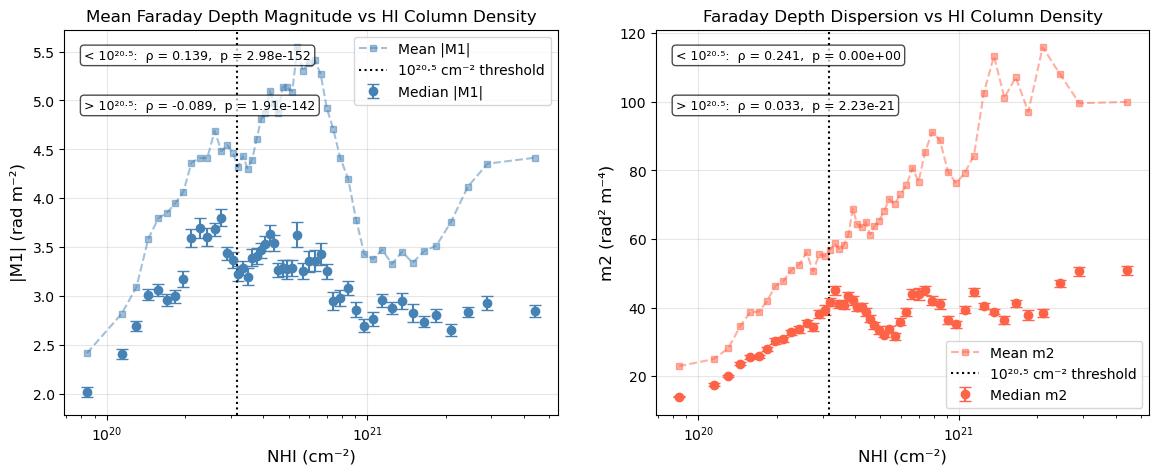

In [142]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].errorbar(binCentresNHI, medianM1NHI, yerr=errM1NHI, fmt='o', color='steelblue',
                 capsize=4, markersize=6, linewidth=1.5, label='Median |M1|')
axes[0].plot(binCentresNHI, meanM1NHI, 's--', color='steelblue',
             alpha=0.5, markersize=5, label='Mean |M1|')
axes[0].axvline(nhiThresh, color='black', linestyle=':', linewidth=1.5,
                label='10²⁰·⁵ cm⁻² threshold')
axes[0].text(0.04, 0.95, f'< 10²⁰·⁵:  ρ = {rhoM1Below:.3f},  p = {pM1Below:.2e}',
             transform=axes[0].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].text(0.04, 0.82, f'> 10²⁰·⁵:  ρ = {rhoM1Above:.3f},  p = {pM1Above:.2e}',
             transform=axes[0].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].set_xlabel('NHI (cm⁻²)', fontsize=12)
axes[0].set_ylabel('|M1| (rad m⁻²)', fontsize=12)
axes[0].set_title('Mean Faraday Depth Magnitude vs HI Column Density', fontsize=12)
axes[0].set_xscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(binCentresNHI, medianM2NHI, yerr=errM2NHI, fmt='o', color='tomato',
                 capsize=4, markersize=6, linewidth=1.5, label='Median m2')
axes[1].plot(binCentresNHI, meanM2NHI, 's--', color='tomato',
             alpha=0.5, markersize=5, label='Mean m2')
axes[1].axvline(nhiThresh, color='black', linestyle=':', linewidth=1.5,
                label='10²⁰·⁵ cm⁻² threshold')
axes[1].text(0.04, 0.95, f'< 10²⁰·⁵:  ρ = {rhoM2Below:.3f},  p = {pM2Below:.2e}',
             transform=axes[1].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1].text(0.04, 0.82, f'> 10²⁰·⁵:  ρ = {rhoM2Above:.3f},  p = {pM2Above:.2e}',
             transform=axes[1].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1].set_xlabel('NHI (cm⁻²)', fontsize=12)
axes[1].set_ylabel('m2 (rad² m⁻⁴)', fontsize=12)
axes[1].set_title('Faraday Depth Dispersion vs HI Column Density', fontsize=12)
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

In [143]:
for i in range(nBins):
    binMask = (nhiValid >= binEdges[i]) & (nhiValid < binEdges[i + 1])
    print(f"Bin {i+1:2d}: n = {np.sum(binMask):6d},  errM2 = {errM2NHI[i]:.3e}")

Bin  1: n =   2335,  errM2 = 1.426e-01
Bin  2: n =   2334,  errM2 = 3.867e-01
Bin  3: n =   2335,  errM2 = 3.704e-01
Bin  4: n =   2334,  errM2 = 4.571e-01
Bin  5: n =   2335,  errM2 = 5.398e-01
Bin  6: n =   2334,  errM2 = 4.917e-01
Bin  7: n =   2335,  errM2 = 6.749e-01
Bin  8: n =   2334,  errM2 = 8.801e-01
Bin  9: n =   2335,  errM2 = 7.430e-01
Bin 10: n =   2334,  errM2 = 7.552e-01
Bin 11: n =   2335,  errM2 = 1.052e+00
Bin 12: n =   2334,  errM2 = 9.462e-01
Bin 13: n =   2335,  errM2 = 1.059e+00
Bin 14: n =   2334,  errM2 = 1.090e+00
Bin 15: n =   2335,  errM2 = 1.382e+00
Bin 16: n =   2334,  errM2 = 1.159e+00
Bin 17: n =   2335,  errM2 = 1.219e+00
Bin 18: n =   2334,  errM2 = 1.168e+00
Bin 19: n =   2335,  errM2 = 1.102e+00
Bin 20: n =   2334,  errM2 = 1.139e+00
Bin 21: n =   2335,  errM2 = 1.397e+00
Bin 22: n =   2334,  errM2 = 1.069e+00
Bin 23: n =   2335,  errM2 = 1.141e+00
Bin 24: n =   2334,  errM2 = 1.230e+00
Bin 25: n =   2334,  errM2 = 1.015e+00
Bin 26: n =   2335,  errM

In [144]:

rhoMedM1, pMedM1 = stats.spearmanr(np.log10(binCentresNHI), medianM1NHI)
rhoMedM2, pMedM2 = stats.spearmanr(np.log10(binCentresNHI), medianM2NHI)

print("Spearman: log10(NHI) bin centres vs bin medians")
print(f"  median |M1|: rho = {rhoMedM1:.3f},  p = {pMedM1:.3e}")
print(f"  median  m2:  rho = {rhoMedM2:.3f},  p = {pMedM2:.3e}")

Spearman: log10(NHI) bin centres vs bin medians
  median |M1|: rho = -0.362,  p = 9.826e-03
  median  m2:  rho = 0.627,  p = 1.123e-06


In [145]:
rhoMeanM1, pMeanM1 = stats.spearmanr(np.log10(binCentresNHI), meanM1NHI)
rhoMeanM2, pMeanM2 = stats.spearmanr(np.log10(binCentresNHI), meanM2NHI)

print("Spearman: log10(NHI) bin centres vs bin means") 
print(f"  mean |M1|: rho = {rhoMeanM1:.3f}, p = {pMeanM1:.3e}")
print(f"  mean  m2 : rho = {rhoMeanM2:.3f}, p = {pMeanM2:.3e}")

Spearman: log10(NHI) bin centres vs bin means
  mean |M1|: rho = -0.001, p = 9.918e-01
  mean  m2 : rho = 0.980, p = 2.814e-35


In [148]:
threshIdx = np.searchsorted(binCentresNHI, nhiThresh)
print(f"Threshold bin index: {threshIdx}")
print(f"Bin centre at threshold index: {binCentresNHI[threshIdx]:.3e} cm-2")

rhoMedM1Below, pMedM1Below = stats.spearmanr(np.log10(binCentresNHI[:threshIdx]), medianM1NHI[:threshIdx])
rhoMedM1Above, pMedM1Above = stats.spearmanr(np.log10(binCentresNHI[threshIdx:]), medianM1NHI[threshIdx:])

rhoMedM2Below, pMedM2Below = stats.spearmanr(np.log10(binCentresNHI[:threshIdx]), medianM2NHI[:threshIdx])
rhoMedM2Above, pMedM2Above = stats.spearmanr(np.log10(binCentresNHI[threshIdx:]), medianM2NHI[threshIdx:])

print("Spearman stats split based on threshold of 10^(20.5)") 
print(f"M1 below: rho = {rhoMedM1Below:.3f}, p = {pMedM1Below:.3e}")
print(f"M1 above: rho = {rhoMedM1Above:.3f}, p = {pMedM1Above:.3e}")
print(f"M2 below: rho = {rhoMedM2Below:.3f}, p = {pMedM2Below:.3e}")
print(F"M2 above: rho = {rhoMedM2Above:.3f}, p = {pMedM2Above:.3e}")

Threshold bin index: 15
Bin centre at threshold index: 3.196e+20 cm-2
Spearman stats split based on threshold of 10^(20.5)
M1 below: rho = 0.832, p = 1.190e-04
M1 above: rho = -0.783, p = 2.783e-08
M2 below: rho = 0.996, p = 2.416e-15
M2 above: rho = 0.122, p = 4.846e-01
